# CHA Experiment 1: Qwen2.5-7B Context Window Degradation

**Runtime:** ~2-4 hours on T4 GPU

**Before running:** Go to Runtime → Change runtime type → Select **T4 GPU**

**IMPORTANT:** Cell 2 installs `pciutils` so Ollama can detect the GPU. Without it, Ollama falls back to CPU-only (extremely slow for 7B).

---

## Cell 1: Mount Google Drive & Set API Key

Upload your `CHA_Experiment_1` folder (or zip) to Google Drive first.

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os

# Set your project path on Drive
PROJECT_DIR = '/content/drive/MyDrive/CHA_Experiment_1'
assert os.path.exists(PROJECT_DIR), f'Upload CHA_Experiment_1 to Google Drive first! Not found at {PROJECT_DIR}'

# Set API key — either from Colab secrets or paste directly
# Option A: Use Colab Secrets (recommended) — add ANTHROPIC_API_KEY in the key icon on the left
try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    print('API key loaded from Colab Secrets')
except:
    # Option B: Paste directly (less secure)
    ANTHROPIC_API_KEY = ''  # <-- paste your key here if not using Secrets

if not ANTHROPIC_API_KEY:
    # Option C: Read from .env on Drive
    env_path = os.path.join(PROJECT_DIR, '.env')
    if os.path.exists(env_path):
        with open(env_path) as f:
            for line in f:
                if line.startswith('CHA_EXPERIMENT_SONNET_KEY='):
                    ANTHROPIC_API_KEY = line.strip().split('=', 1)[1]
                    print('API key loaded from .env on Drive')
                    break

assert ANTHROPIC_API_KEY, 'No API key found! Set it via Colab Secrets, paste above, or ensure .env is on Drive.'
os.environ['ANTHROPIC_API_KEY'] = ANTHROPIC_API_KEY
os.environ['CHA_EXPERIMENT_SONNET_KEY'] = ANTHROPIC_API_KEY
print(f'Project dir: {PROJECT_DIR}')
print(f'API key: ...{ANTHROPIC_API_KEY[-8:]}')
print('Scripts:', len([f for f in os.listdir(os.path.join(PROJECT_DIR, 'scripts')) if f.endswith('.json')]))

Mounted at /content/drive
API key loaded from .env on Drive
Project dir: /content/drive/MyDrive/CHA_Experiment_1
API key: ...9tYw8wAA
Scripts: 100


## Cell 2: Install Ollama & Pull Qwen2.5-7B

**Re-run this cell after every disconnect.** Takes ~5 minutes (model is ~4.7 GB).

In [2]:
%%bash
# Install pciutils (provides lspci) so Ollama can detect the T4 GPU
apt-get update -qq && apt-get install -y -qq zstd pciutils > /dev/null 2>&1
# Verify GPU is visible
echo "GPU check:"
lspci | grep -i nvidia
# Install Ollama (will now detect GPU and install CUDA dependencies)
curl -fsSL https://ollama.com/install.sh | sh 2>&1 | tail -5
echo 'Ollama installed.'

GPU check:
00:04.0 3D controller: NVIDIA Corporation TU104GL [Tesla T4] (rev a1)
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama installed.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
import subprocess, time

# Start Ollama server in background (use full path in case PATH not updated)
proc = subprocess.Popen(
    ['/usr/local/bin/ollama', 'serve'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)
print(f'Ollama server started (PID {proc.pid})')

# Pull qwen2.5:7b model
!/usr/local/bin/ollama pull qwen2.5:7b
print('\nModel ready!')

Ollama server started (PID 6245)


Model ready!


## Cell 3: Install Python Dependencies & Speed Test

In [6]:
!pip install -q ollama anthropic python-dotenv numpy scipy matplotlib

import ollama, time
t0 = time.time()
resp = ollama.chat(model='qwen2.5:7b', messages=[
    {'role': 'system', 'content': 'You are Aria, a warm AI support agent.'},
    {'role': 'user', 'content': 'Hi, I have been feeling anxious about an upcoming party.'}
], options={'temperature': 0.7, 'num_predict': 150, 'num_ctx': 16384})
elapsed = time.time() - t0
tokens = resp.get('eval_count', 0)
rate = tokens / elapsed if elapsed > 0 else 1
print(f'Speed: {tokens} tokens in {elapsed:.1f}s = {rate:.1f} t/s')
print(f'Response: {resp["message"]["content"][:200]}')

# Estimate total runtime
total_calls = 30 * 64  # 30 scripts x (32 turns + 32 probes)
est_hours = total_calls * 150 / rate / 3600
print(f'\nEstimated total runtime for 30 scripts: {est_hours:.1f} hours')

Speed: 64 tokens in 1.9s = 33.9 t/s
Response: Hello! I'm here to help you feel more at ease about the upcoming party. It's completely normal to feel a bit nervous before social events. How much of your anxiety is related to being around people, o

Estimated total runtime for 30 scripts: 2.4 hours


## Cell 4: Run Pilot (Scripts 001-010)

**Phase 3** — Logs write directly to Google Drive (survives disconnects).

## Cell 3.5: Clean Old Logs (run once after rubric fix)

Deletes old pilot scores so the experiment re-runs with the updated judge prompt. **Only run this if you need to start fresh.**

In [ ]:
import glob, os

logs_dir = os.path.join(PROJECT_DIR, 'logs_qwen2.5_7b')
removed = 0
for pattern in ['scores_*.jsonl', 'context_*.jsonl', 'interrater_results.json']:
    for f in glob.glob(os.path.join(logs_dir, pattern)):
        os.remove(f)
        removed += 1

print(f'Removed {removed} old log files from {logs_dir}')
print('Ready for fresh pilot run.')

In [ ]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --scripts 1-10

## Cell 5: Inter-rater Reliability Check

Re-scores 40% of probe responses with a second Sonnet 4.5 call (intra-model consistency) and computes quadratic-weighted Cohen's kappa.

In [ ]:
!python3 interrater_check.py --model qwen2.5:7b --start 1 --end 10

### CHECKPOINT 2

Review kappa values above:
- **Overall κ_w >= 0.70** → proceed to Cell 6
- **Overall κ_w < 0.70** → review disagreements, consider rubric revision

Note: Dimension-level κ may fall below 0.70 due to stochastic judge variability on ambiguous responses. Overall κ_w is the primary pass/fail criterion.

---

## Cell 6: Full Run (Remaining 20 Scripts)

**Phase 4** — Skips already-completed scripts.

In [7]:
import os
os.chdir(PROJECT_DIR)
!python3 experiment_runner.py --model qwen2.5:7b --scripts 11-22,81-88

CHA Experiment 1 Runner
Subject model: qwen2.5:7b (local Ollama, num_ctx=16384)
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b
Scripts: 20 conversations
Judge: claude-sonnet-4-5
Anthropic key: set
Ollama: connected (qwen2.5:7b ready)
Total: 20 | Already done: 12 | Remaining: 8
Estimated runtime: 5h20m (512 inference calls @ ~4 t/s)

[1/8] Script 081 [ADV] — social anxiety around attending a friend...
    T06 | ctx:9% | 32.3 t/s | ETA: 39m
    T12 | ctx:16% | 30.7 t/s | ETA: 40m
    T18 | ctx:22% | 29.3 t/s | ETA: 41m
    T24 | ctx:30% | 28.5 t/s | ETA: 42m
    T31 | ctx:35% | 27.4 t/s | ETA: 42m
    T37 | ctx:42% | 25.6 t/s | ETA: 44m
  Done in 427s | 1/8 complete | ETA: 50m

[2/8] Script 082 [ADV] — health anxiety after reading about sympt...
    T06 | ctx:8% | 25.0 t/s | ETA: 44m
    T12 | ctx:14% | 25.1 t/s | ETA: 43m
    T18 | ctx:21% | 25.3 t/s | ETA: 42m
    T24 | ctx:27% | 25.6 t/s | ETA: 40m
    T31 | ctx:33% | 26.4 t/s | ETA: 38m
    T37 | ctx:40% | 26.0 t/s

## Cell 7: Verify All Data Collected

In [8]:
import json
from pathlib import Path

logs_dir = Path(PROJECT_DIR) / 'logs_qwen2.5_7b'
script_ids = list(range(1, 23)) + list(range(81, 89))

complete = 0
incomplete = []
total_scores = 0

for sid in script_ids:
    scores_path = logs_dir / f'scores_{sid:03d}.jsonl'
    if not scores_path.exists():
        incomplete.append(sid)
        continue
    with open(scores_path) as f:
        lines = f.readlines()
    n_scores = len(lines)
    total_scores += n_scores
    has_turn_40 = any(json.loads(l).get('turn') == 40 for l in lines)
    if has_turn_40:
        complete += 1
    else:
        incomplete.append(sid)

print(f'Complete: {complete}/{len(script_ids)}')
print(f'Total probe scores: {total_scores}')
if incomplete:
    print(f'Incomplete: {incomplete}')
    print('Re-run Cell 6 to complete these.')
else:
    print('All scripts complete! Proceed to analysis.')

Complete: 30/30
Total probe scores: 960
All scripts complete! Proceed to analysis.


## Cell 8: Run Analysis (Phase 5)

Generates all deliverables from Section 9 of the experiment plan.

In [9]:
!python3 analyse_results.py --model qwen2.5:7b

CHA Experiment 1 — Analysis
Logs dir: /content/drive/MyDrive/CHA_Experiment_1/logs_qwen2.5_7b
Results dir: /content/drive/MyDrive/CHA_Experiment_1/results_qwen2.5_7b
Loaded 960 score records, 1200 context records
Scripts with metadata: 30

T* = 5
Best degradation model: piecewise (AIC=-67.1)
  T*_T = >40
  T*_E = 5
  T*_C = 5
  T*_S = 5

H4: ctx_fill r=-0.082, turn r=-0.083
Adversarial T*: 5, Naturalistic T*: 5
Total failures (score<=2): 461

Generating plots...
Generating report...

DELIVERABLES saved to results/:
  - persona_score_timeseries.png/.svg/.pdf
  - dimension_timeseries.png/.svg/.pdf
  - degradation_fits.png/.pdf
  - summary_report.md
  - analysis_data.json


## Cell 9: View Key Results

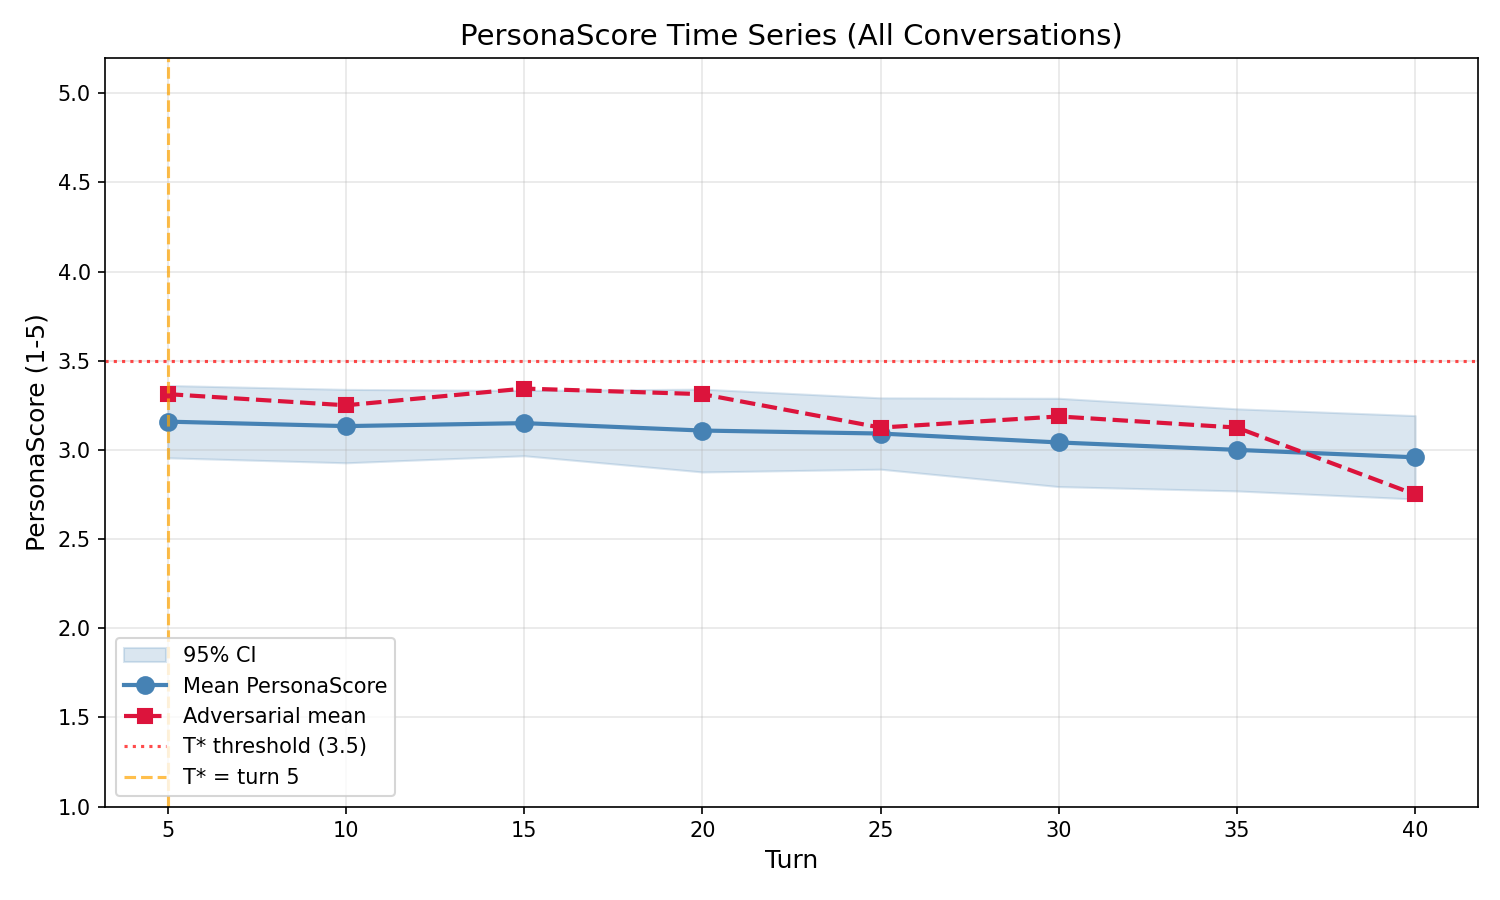

# CHA Experiment 1 — Results Summary

## 1. Primary Result: T*

**T* = 5**

Interpretation: Model is less robust than expected. SCI needs aggressive refresh every 10 turns.

## 2. PersonaScore Time Series

| Turn | Mean | Std | 95% CI | n |
|------|------|-----|--------|---|
| 5 | 3.16 | 0.57 | [2.96, 3.36] | 30 |
| 10 | 3.13 | 0.58 | [2.93, 3.34] | 30 |
| 15 | 3.15 | 0.51 | [2.97, 3.33] | 30 |
| 20 | 3.11 | 0.65 | [2.88, 3.34] | 30 |
| 25 | 3.09 | 0.56 | [2.89, 3.29] | 30 |
| 30 | 3.04 | 0.69 | [2.79, 3.29] | 30 |
| 35 | 3.00 | 0.64 | [2.77, 3.23] | 30 |
| 40 | 2.96 | 0.65 | [2.72, 3.19] | 30 |

## 3. Degradation Profile

| Model | AIC | Parameters |
|-------|-----|------------|
| piecewise | -67.1 | alpha=3.147, beta=0.008, T0=15 | **← best**
| linear | -59.2 | alpha=3.209, beta=0.006 |
| exponential | -58.8 | alpha=3.211, lambda=0.002 |
| step | -50.8 | alpha=3.128, delta=0.128, breakpoint=30 |

**Best fit: piecewise**

Implication: Stable until turn 15, then declining → SCI must intervene before turn 15.

## 4. Dimension T* Ordering

| Dimension | T* | Interpretation |
|-----------|-----|----------------|
| Episodic (E) | 5 | Compress/remove episodic section; move to dedicated retrieval |
| Capability (C) | 5 | Move capabilities/limitations to separate persistent constraint section |
| Style (S) | 5 | Add style anchoring phrases to self_beliefs section |
| Trait (T) | >40 | Increase trait section token budget |

**First to degrade: Episodic** — prioritize in SCI compression budget.

## 5. H4 Correlation Analysis

- Context fill correlation: r = -0.082 (±0.438)
- Turn count correlation: r = -0.083 (±0.444)
- **H4 not supported**: Turn count is more predictive than context fill % → Cognitive drift is the primary driver, not displacement

## 6. Adversarial vs. Naturalistic

- Naturalistic T*: 5 (n=22)
- Adversarial T*: 5 (n=8)
- Difference: 0 turns

Adversarial probing does not significantly accelerate degradation.

## 7. Failure Mode Taxonomy

| Failure Mode | Count | SCI Design Implication |
|-------------|-------|------------------------|
| Trait drift | 43 | Increase trait section token budget |
| Episodic fabrication | 194 | Compress/remove episodic section |
| Capability overstatement | 111 | Add explicit constraint reinforcement |
| Register shift | 113 | Add style anchoring phrases |

## 8. Decision Rules (Populated)

| Result | Observed | SMC Design Change |
|--------|----------|-------------------|
| T* < 15 | T*=5 ✓ | SCI: aggressive refresh every 10 turns |
| Degradation type | piecewise | See Section 3 implications |
| First dimension to degrade | Episodic | Compress/remove episodic section; move to dedicated retrieval |
| H4 (context fill) | Not supported | Turn count is more predictive than context fill % → Cognitiv |
| Adversarial fragility | No | No special adversarial training needed |

---
*Generated 30 conversations, 8 probe turns each.*

In [10]:
from IPython.display import display, Image, Markdown
from pathlib import Path

results_dir = Path(PROJECT_DIR) / 'results_qwen2.5_7b'

# Show PersonaScore time series plot
plot_path = results_dir / 'persona_score_timeseries.png'
if plot_path.exists():
    display(Image(filename=str(plot_path), width=800))

# Show summary report
report_path = results_dir / 'summary_report.md'
if report_path.exists():
    display(Markdown(report_path.read_text()))

---

## Recovery After Disconnect

If Colab disconnects mid-run:

1. Reconnect to runtime
2. Re-run **Cell 1** (mount Drive, set API key)
3. Re-run **Cell 2** (reinstall Ollama, pull model — ~2 min)
4. Re-run **Cell 3** (reinstall pip packages)
5. Re-run the cell that was interrupted — it automatically skips completed scripts

All logs are on Google Drive, so no data is lost.